In [53]:
### IMPORTING ALL THE NECCESSARY LIBRARIES

import yfinance as yf
import pandas as pd
import os
import sagemaker
import boto3
import sklearn
import matplotlib
from sklearn.pipeline import Pipeline

In [54]:
# importing the data through yfinance library
nse = yf.Ticker("^NSEI")
nse = nse.history(period = "max")

In [55]:
nse

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,0.0,0.0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,0.0,0.0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,0.0,0.0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,0.0,0.0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,0.0,0.0
...,...,...,...,...,...,...,...
2023-12-05 00:00:00+05:30,20808.900391,20864.050781,20711.150391,20855.099609,421000,0.0,0.0
2023-12-06 00:00:00+05:30,20950.750000,20961.949219,20852.150391,20937.699219,359200,0.0,0.0
2023-12-07 00:00:00+05:30,20932.400391,20941.250000,20850.800781,20901.150391,275000,0.0,0.0


<Axes: xlabel='Date'>

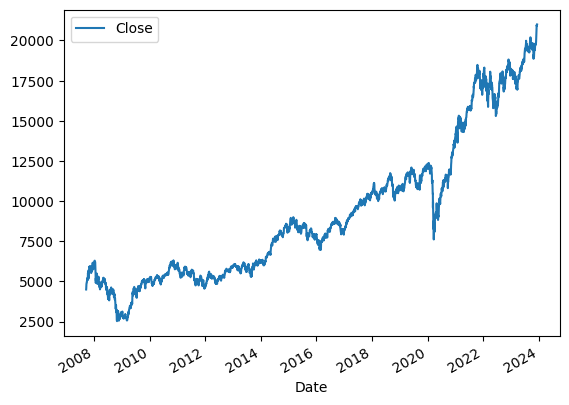

In [56]:

# Chart of NSE
nse.plot.line(y="Close", use_index=True)

In [57]:
# Feature Engineering
del nse['Dividends']
del nse['Stock Splits']
nse["tomorrow"]=nse["Close"].shift(-1)
nse["target"]=(nse["tomorrow"]>nse["Close"]).astype(int)

In [58]:
nse

,Open,High,Low,Close,Volume,tomorrow,target
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195,1
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098,1
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805,1
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805,1
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195,1
...,...,...,...,...,...,...,...
2023-12-05 00:00:00+05:30,20808.900391,20864.050781,20711.150391,20855.099609,421000,20937.699219,1
2023-12-06 00:00:00+05:30,20950.750000,20961.949219,20852.150391,20937.699219,359200,20901.150391,0
2023-12-07 00:00:00+05:30,20932.400391,20941.250000,20850.800781,20901.150391,275000,20969.400391,1


In [59]:
# Saving the Data till the date, for future ref!!
nse.to_csv('nse_data',index=True)

In [60]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200,min_samples_split=100,random_state=1)

In [61]:
train = nse.iloc[:-100]
test= nse.iloc[-100:]

In [62]:
train.to_csv('train-v-1',index=False)
test.to_csv('test-v-1',index=False)

In [63]:
x=["Close","Open","High","Low","Volume"]
y = "target"

In [64]:

model.fit(train[x],train[y])

RandomForestClassifier(min_samples_split=100, n_estimators=200, random_state=1)

In [65]:
from sklearn.metrics import precision_score

preds = model.predict(test[x])
preds = pd.Series(preds, index=test.index)
precision_score(test[y], preds)


0.56

In [66]:
test['preds']=preds
test.head()

/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_2492/3282017769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['preds']=preds


,Open,High,Low,Close,Volume,tomorrow,target,preds
Date,,,,,,,,
2023-07-17 00:00:00+05:30,19612.150391,19731.849609,19562.949219,19711.449219,268700,19749.250000,1,1
2023-07-18 00:00:00+05:30,19787.500000,19819.449219,19690.199219,19749.250000,286400,19833.150391,1,1
2023-07-19 00:00:00+05:30,19802.949219,19851.699219,19727.449219,19833.150391,259700,19979.150391,1,1
2023-07-20 00:00:00+05:30,19831.699219,19991.849609,19758.400391,19979.150391,274700,19745.000000,0,1
2023-07-21 00:00:00+05:30,19800.449219,19887.400391,19700.000000,19745.000000,312500,19672.349609,0,1


<Axes: xlabel='Date'>

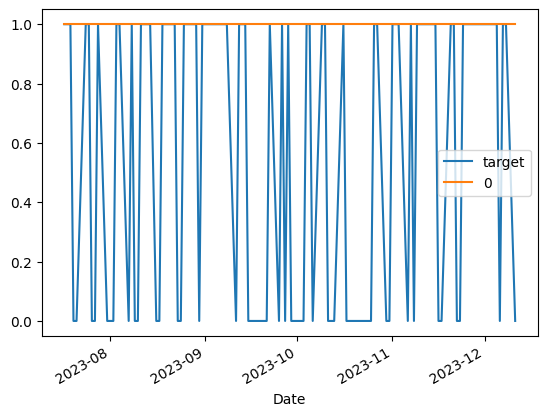

In [67]:
combined = pd.concat([test["target"], preds], axis=1)
combined.plot()

In [74]:
def predict(train, test, x, model):
    model.fit(train[x], train["target"])
    preds = model.predict(test[x])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["target"], preds], axis=1)
    return combined

In [75]:
def backtest(data, model, x, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, x, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [76]:

predictions = backtest(nse, model, x)

In [77]:

predictions["Predictions"].value_counts()

Predictions
1    745
0    734
Name: count, dtype: int64

In [78]:

predictions["target"].value_counts() / predictions.shape[0]

target
1    0.546315
0    0.453685
Name: count, dtype: float64

In [83]:

precision_score(predictions["target"], predictions["Predictions"])

0.5463087248322148

In [84]:

predictions["target"].value_counts() / predictions.shape[0]

target
1    0.546315
0    0.453685
Name: count, dtype: float64

In [85]:
predictions


,target,Predictions
Date,,
2017-12-08 00:00:00+05:30,1,1
2017-12-11 00:00:00+05:30,0,1
2017-12-12 00:00:00+05:30,0,1
2017-12-13 00:00:00+05:30,1,1
2017-12-14 00:00:00+05:30,1,1
...,...,...
2023-12-05 00:00:00+05:30,1,0
2023-12-06 00:00:00+05:30,0,0
2023-12-07 00:00:00+05:30,1,0
